# Correlation between BDI and DI at the plateau
20260427
Author: Kyoko Kusano

To test the hypotheses that 
 1. There is a significant correlation between BDI and DI (genmag) at the plateau (t=10000)
2. There is a significant difference between the BDI high-group (top 20) and low-group (bottom 20)

In [38]:
import os
import sys
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter



from qstr_diversity import core, viz

In [48]:
from qstr_dataset import paths
h5_path = paths.interim("amy_processeddata_all.h5")
with pd.HDFStore(h5_path, mode="r") as store:
    genmag = store["/metrics/genmag"]
    spr = store["/metrics/spread"]
    positive_definite_t_all = store["/metrics/positivedefinite"]

,1.000000e-04,1.412538e-04,1.995262e-04,2.818383e-04,3.981072e-04,5.623413e-04,7.943282e-04,1.122018e-03,1.584893e-03,2.238721e-03,...,1.274275e+06,2.069138e+06,3.359818e+06,5.455595e+06,8.858668e+06,1.438450e+07,2.335721e+07,3.792690e+07,6.158482e+07,1.000000e+08
0,1.000376,1.000531,1.000750,1.001060,1.001497,1.002114,1.002985,1.004215,1.005950,1.008396,...,9.1,9.1,9.1,9.1,9.1,9.1,9.1,9.1,9.1,9.1
1,1.000506,1.000714,1.001009,1.001425,1.002014,1.002844,1.004018,1.005677,1.008021,1.011335,...,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0,18.0
2,1.000604,1.000847,1.001186,1.001656,1.002305,1.003200,1.004433,1.006129,1.008473,1.011725,...,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0
3,1.000653,1.000921,1.001301,1.001837,1.002592,1.003657,1.005156,1.007266,1.010229,1.014385,...,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0
4,1.000486,1.000687,1.000969,1.001369,1.001933,1.002728,1.003850,1.005432,1.007659,1.010791,...,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.000361,1.000510,1.000720,1.001017,1.001437,1.002030,1.002867,1.004050,1.005721,1.008082,...,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0,12.0
116,1.000378,1.000534,1.000755,1.001066,1.001506,1.002127,1.003004,1.004242,1.005991,1.008460,...,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0,11.0
117,1.000377,1.000532,1.000751,1.001061,1.001498,1.002114,1.002984,1.004210,1.005935,1.008360,...,16.0,16.0,16.0,16.0,16.0,16.0,16.0,16.0,16.0,16.0
118,1.000308,1.000435,1.000615,1.000868,1.001226,1.001730,1.002442,1.003445,1.004857,1.006841,...,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0


In [59]:
genmag_plateau = np.array(genmag.iloc[:, -1])
genmag_plateau = np.column_stack((np.arange(200, dtype=int), genmag_plateau))
genmag_plateau = pd.DataFrame(genmag_plateau, columns=["Sub", "DI"])

d_path = paths.source("Amy_pilot", "raw", "BDI_score.csv")
bdi = pd.read_csv(d_path)

In [42]:
# === 1. データの準備と結合 ===

# "Sub"をキーにして2つのDataFrameを結合
df_merged = pd.merge(genmag_plateau, bdi, on="Sub")
df_merged = df_merged[df_merged["DI"]>0]
df_merged

,Sub,DI,BDI
0,0.0,9.1,0
1,1.0,18.0,0
2,2.0,20.0,0
3,3.0,11.0,0
4,4.0,22.0,0
...,...,...,...
115,115.0,12.0,34
116,116.0,11.0,36
117,117.0,16.0,38
118,118.0,17.0,39


In [49]:
genmag_col = genmag_plateau.columns[1]
bdi_col = bdi.columns[1]

# === 2. 検定1の事前検証（正規性の検定） ===
# Shapiro-Wilk検定（p > 0.05 なら正規性ありと仮定）
_, p_norm_g = stats.shapiro(df_merged[genmag_col])
_, p_norm_b = stats.shapiro(df_merged[bdi_col])

print(f"・{genmag_col}'s normality (Shapiro-Wilk): p = {p_norm_g:.4f}")
print(f"・{bdi_col}'s normality (Shapiro-Wilk): p = {p_norm_b:.4f}")

# === 3. 検定1の本検定（相関） ===
alpha = 0.05
if p_norm_g > alpha and p_norm_b > alpha:
    print("→ Normality was confirmed. Calculate Pearson correlation coefficient")
    corr, p_corr = stats.pearsonr(df_merged[genmag_col], df_merged[bdi_col])
else:
    print("→ Normality was denied. Calculate Spearman's rank correlation coefficient")
    corr, p_corr = stats.spearmanr(df_merged[genmag_col], df_merged[bdi_col])

print(f"Correlation coefficient: {corr:.4f}, p-val: {p_corr:.4e}\n")

・DI's normality (Shapiro-Wilk): p = 0.0013
・BDI's normality (Shapiro-Wilk): p = 0.0000
→ Normality was denied. Calculate Spearman's rank correlation coefficient
Correlation coefficient (r/rho): -0.0386, p-val: 6.7687e-01



In [60]:
# print("========== 検定2：BDIトップ20名とボトム20名の差 ==========")
# === 4. グループの抽出 ===
# BDIスコアで降順（高い順）にソート
df_sorted = df_merged.sort_values(by=bdi_col, ascending=False)

# トップ20名とボトム20名のgenmag_plateauの値を抽出
top20_vals = df_sorted.head(20)[genmag_col]
bot20_vals = df_sorted.tail(20)[genmag_col]

# === 5. 検定2の事前検証（正規性と等分散性の検定） ===
# 正規性の検定 (Shapiro-Wilk)
_, p_norm_top = stats.shapiro(top20_vals)
_, p_norm_bot = stats.shapiro(bot20_vals)
print(f"・トップ20群の正規性: p = {p_norm_top:.4f}")
print(f"・ボトム20群の正規性: p = {p_norm_bot:.4f}")

# 等分散性の検定 (Levene検定: 正規性から外れていても比較的頑健)
_, p_levene = stats.levene(top20_vals, bot20_vals)
print(f"・2群間の等分散性 (Levene検定): p = {p_levene:.4f}")

# === 6. 検定2の本検定（2群間の差） ===
if p_norm_top > alpha and p_norm_bot > alpha:
    # 両群ともに正規性がある場合
    if p_levene > alpha:
        print("→ [判定] 正規性と等分散性が仮定できます。Studentのt検定を使用します。")
        stat_val, p_diff = stats.ttest_ind(top20_vals, bot20_vals, equal_var=True)
        test_name = "t-val (Student)"
    else:
        print("→ [判定] 正規性はありますが、等分散性が棄却されました。Welchのt検定を使用します。")
        stat_val, p_diff = stats.ttest_ind(top20_vals, bot20_vals, equal_var=False)
        test_name = "t-val (Welch)"
else:
    # 少なくとも一方の正規性がない場合
    print("→ [判定] 正規性が棄却されました。マン・ホイットニーのU検定を使用します。")
    stat_val, p_diff = stats.mannwhitneyu(top20_vals, bot20_vals, alternative='two-sided')
    test_name = "U-val (Mann-Whitney)"

print(f"{test_name}: {stat_val:.4f}, p-val: {p_diff:.4e}")

・トップ20群の正規性: p = 0.0771
・ボトム20群の正規性: p = 0.3776
・2群間の等分散性 (Levene検定): p = 0.2255
→ [判定] 正規性と等分散性が仮定できます。Studentのt検定を使用します。
t-val (Student): -0.0972, p-val: 9.2310e-01


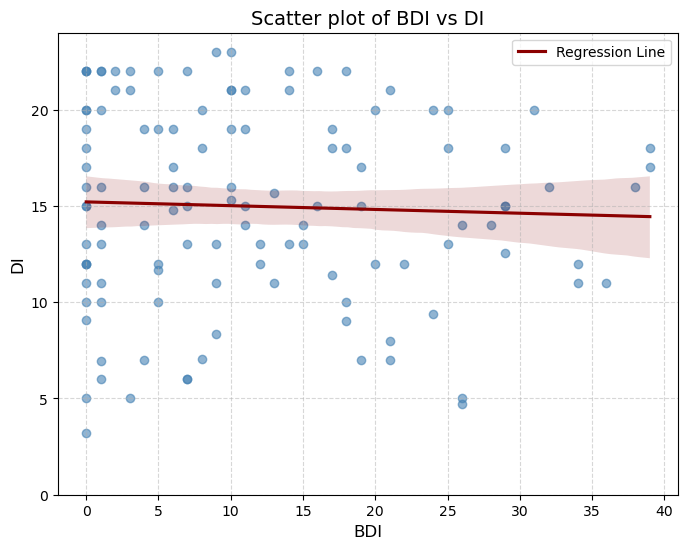

In [45]:
plt.figure(figsize=(8, 6))

# 散布図と回帰直線の描画
sns.regplot(data=df_merged, x=bdi_col, y=genmag_col, 
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'}, # ドットの透明度と色
            line_kws={'color': 'darkred', 'label': 'Regression Line'}) # 回帰直線の色
plt.ylim([0, 24])

# タイトルと軸ラベルの設定
plt.title('Scatter plot of BDI vs DI', fontsize=14)
plt.xlabel('BDI', fontsize=20)
plt.ylabel('DI', fontsize=20)

# グリッド線と凡例の表示
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# グラフの表示
plt.show()

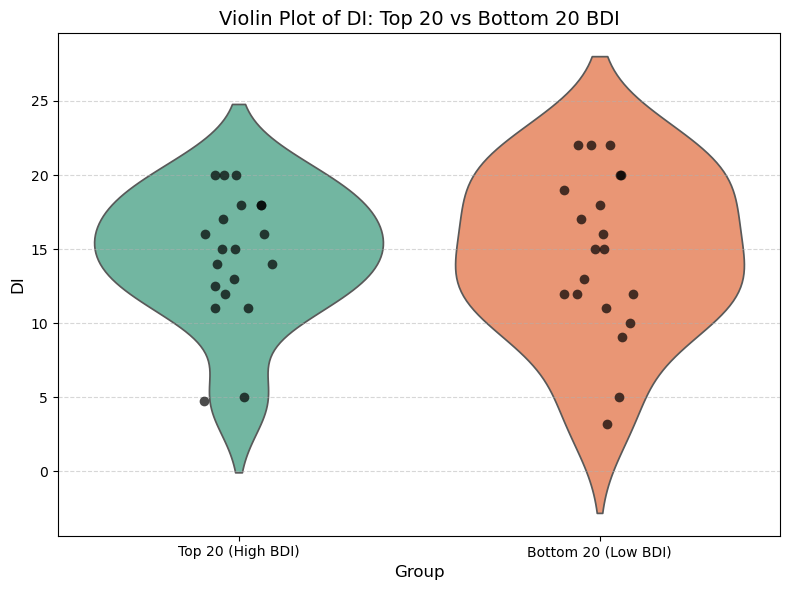

In [61]:
# 1. 可視化用データの準備
# BDIスコアで降順（高い順）にソート
df_sorted = df_merged.sort_values(by=bdi_col, ascending=False)

# トップ20名とボトム20名を抽出し、それぞれにグループ名（ラベル）を付与
df_top = df_sorted.head(20).copy()
df_top['Group'] = 'Top 20 (High BDI)'

df_bot = df_sorted.tail(20).copy()
df_bot['Group'] = 'Bottom 20 (Low BDI)'

# 縦方向に結合してプロット用のデータフレーム（計24行）を作成
df_plot = pd.concat([df_top, df_bot])

# 2. グラフの描画
plt.figure(figsize=(8, 6))

# バイオリンプロットを描画
# inner=None にすることで中の箱ひげ図を消し、上の散布図を見やすくします
sns.violinplot(data=df_plot, x='Group', y=genmag_col, 
               hue='Group', palette='Set2', legend=False, inner=None)

# 元のデータ点を重ねて散布図として描画
# jitter=True によって点が垂直に重なるのを防ぎ、左右に少し散らします
sns.stripplot(data=df_plot, x='Group', y=genmag_col, 
              color='black', alpha=0.7, jitter=True, size=7)

# 3. 見栄えの調整
plt.title('Violin Plot of DI: Top 20 vs Bottom 20 BDI', fontsize=14)
plt.xlabel('Group', fontsize=12)
plt.ylabel('DI', fontsize=12)

# y軸のみグリッド線を追加
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()